In [10]:
from IPython.display import display, HTML
from bs4 import BeautifulSoup
import re
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
import plotly.graph_objects as go

import pandas as pd
from scipy.io import readsav

%run Functions.ipynb

In [75]:
from cdasws import CdasWs
cdas = CdasWs()
#status, sta_data = cdas.get_data('STA_COHO1HR_MERGED_MAG_PLASMA', ['BR','BT','BN','plasmaDensity','plasmaTemp','plasmaSpeed'],
#                     '2023-04-21T18:00:00Z', '2023-04-27T18:00:00Z')

status, sta_data = cdas.get_data('STA_L2_MAGPLASMA_1M', ['BFIELDRTN','Np','Vth','Vp'],
                     '2023-04-23T00:00:00Z', '2023-04-26T00:00:00Z') #'2023-04-21T18:00:00Z', '2023-04-27T18:00:00Z')

FILLVAL = np.float32(-1e+31)
# Create DataFrame
sta = pd.DataFrame({
    'Epoch': sta_data['Epoch'],
    'B_R': sta_data['BFIELDRTN'][:,0],
    'B_T': sta_data['BFIELDRTN'][:,1],
    'B_N': sta_data['BFIELDRTN'][:,2],
    'N' : sta_data['Np'],
    'T' : sta_data['Vth'],
    'V' : sta_data['Vp']
})
 
# Replace FILLVAL with NaN and drop those rows
sta.replace(FILLVAL, np.nan, inplace=True)
sta.dropna(subset=['B_R', 'B_T', 'B_N', 'N', 'T', 'V'], inplace=True)

sta['B'] = np.sqrt(sta['B_R']**2 + sta['B_T']**2 + sta['B_N']**2)

#Compute and store Beta_proton
kBz = np.float64(1.3806503e-23)        # Boltzmann constant (kg*m^2)/(K*s^2)
mu0 = np.float64(4.0 * np.pi * 1e-7)   # Permeability of  free space (H/m) = (N/A^2) = (kg*m/s^2)/A^2; A = kg/(T*s^2)

Pplasma_sta = 1e6*sta['N'] * kBz * sta['T']         # Plasma pressure (kg/(m*s^2)) a.k.a. (Pa); (need Np in m^-3 not cm^-3; T in K) [Thermal Pressure?]
Pmag_sta = (sta['B'] * 1e-9)**2 / (2.0 * mu0)     # Magnetic pressure (kg/(m*s^2)) (need B in T not nT)
ibt = (Pplasma_sta != 0) & (Pmag_sta != 0)  

betaplm_sta = np.zeros_like(Pplasma_sta)
betaplm_sta[ibt] = Pplasma_sta[ibt]/Pmag_sta[ibt]
sta['Beta_p'] = betaplm_sta


status1, WIND_MFIdata = cdas.get_data('WI_H1_SWE_RTN', ['BR', 'BT', 'BN'],
                      '2023-04-23T00:00:00Z', '2023-04-26T00:00:00Z') #'2023-04-21T18:00:00Z', '2023-04-27T18:00:00Z')#'WI_K1-RTN_MFI', ['BF1', 'BRTN'],

if WIND_MFIdata is None:
    print("Error: No data returned from cdas.get_data.")
else:
    WIND_MFI = pd.DataFrame({
        'Epoch': WIND_MFIdata['Epoch'],
        'B_R': WIND_MFIdata['BR'],
        'B_T': WIND_MFIdata['BT'],
        'B_N': WIND_MFIdata['BN']
    })

#'B_N': WIND_MFIdata['BRTN'][:,2]

status2, WIND_PLAdata = cdas.get_data('WI_H1_SWE_RTN', ['Proton_V_moment','Proton_Np_moment', 'Proton_W_moment'],
                      '2023-04-23T00:00:00Z', '2023-04-26T00:00:00Z') #'2023-04-21T18:00:00Z', '2023-04-27T18:00:00Z')

# Create DataFrame
if WIND_PLAdata is None:
    print("Error: No data returned from cdas.get_data.")
else:
    WIND_PLA = pd.DataFrame({
        'Epoch': WIND_PLAdata['Epoch'],
        'N' : WIND_PLAdata['Proton_Np_moment'],
        'T' : WIND_PLAdata['Proton_W_moment'],
        'V' : WIND_PLAdata['Proton_V_moment']
    })

WIND_MFI['B'] = np.sqrt(WIND_MFI['B_R']**2 + WIND_MFI['B_T']**2 + WIND_MFI['B_N']**2)
#WIND_PLA['V'] = np.sqrt(WIND_PLA['V_R']**2 + WIND_PLA['V_T']**2 + WIND_PLA['V_N']**2)

#status, ert_data = cdas.get_data('OMNI_COHO1HR_MERGED_MAG_PLASMA', ['BR','BT','BN','N', 'V'],
#                     '2023-04-21T18:00:00Z', '2023-04-27T18:00:00Z')
## Create DataFrame
#ert = pd.DataFrame({
#    'Epoch': ert_data['Epoch'],
#    'BR': ert_data['BR'],
#    'BT': ert_data['BT'],
#    'BN': ert_data['BN'],
#    'N' : ert_data['N'],
#    'V' : ert_data['V']
#})
 
#sta['B'] = np.sqrt(sta['BR']**2 + sta['BT']**2 + sta['BN']**2)
#ert['B'] = np.sqrt(ert['BR']**2 + ert['BT']**2 + ert['BN']**2)



In [84]:
#Compute and store Beta_proton

Pplasma_wind = 1e6*WIND_PLA['N'] * kBz * WIND_PLA['T']         # Plasma pressure (kg/(m*s^2)) a.k.a. (Pa); (need Np in m^-3 not cm^-3; T in K) [Thermal Pressure?]
Pmag_wind = (WIND_MFI['B'] * 1e-9)**2 / (2.0 * mu0)     # Magnetic pressure (kg/(m*s^2)) (need B in T not nT)
ibt = (Pplasma_wind != 0) & (Pmag_wind != 0)  

betaplm_wind = np.zeros_like(Pplasma_wind)
betaplm_wind[ibt] = Pplasma_wind[ibt]/Pmag_wind[ibt]
WIND_PLA['Beta_p'] = betaplm_wind

#dst_0 = [-17,-16,-20,-29,-29,-27,-29,-29,-22,-19,-19,-21,-15,-9,-10,-9,-9,-8,-8,-6,-6,-8,-8,-9,-11,-12,-15,-11,-9,-9,
dst_0 = [-14,-15,-11,-11,-11,-12,-14,-10,-8,-13,-27,-30,-35,-33,-38,-49,-56,-61,-81,-109,-129,-165,-149,-140,-147,-146,-179,-199,-209,-213,-208,-180,-161,-157,-148,-125,-118,-118,-112,-99,-96,-89,-84,-73,-74,-71,-59,-56,-57,-56,-56,-57,-61,-63,-61,-58,-56,-52,-47,-43,-42,-43,-45,-49,-46,-41,-40,-35,-35,-43,-44,-42]
#,-43,-41,-38,-44,-45,-45,-44,-42,-39,-35,-36,-31,-24,-28,-31,-32,-33,-36,-32,-35,-35,-31,-28,-25,-21,-19,-22,-28,-41,-45,-42,-49,-51,-45,-49,-35,-31,-33,-41,-43,-43]
Dst_00 = np.zeros(2056) - 999

for i in range(len(dst_0)):
    index = 24 + i * 30
    if index < len(Dst_00):
        Dst_00[index] = dst_0[i]

Dst_data = pd.DataFrame({
        'Epoch': WIND_MFI['Epoch'],
        'Dst': Dst_00})

In [150]:
import matplotlib.pyplot as plt

def plot_data(WIND_MFI, WIND_PLA, data_list, vlines, filename, figsize=(6,10),fontsize=20):

    fig, axs = plt.subplots(len(data_list), figsize=figsize)
    
    for i, data in enumerate(data_list):
        # Extract data from dictionary
        dataset = data['dataset']
        x_col = data['x_col']
        variables = data['variables'] 
        colors = data.get('colors', ['black'] * len(variables)) 
        markers = data.get('markers', ['.'] * len(variables))  
        markersize = data.get('markersize',None)  
        labels = data.get('labels', [None] * len(variables))  
        ylabel = data.get('ylabel', '')
        ylim = data.get('ylim', None)
        xlim = data.get('xlim', None)
        xlabel = data.get('xlabel', False)
        xticklabel = data.get('xticklabel', None)
        xtick = data.get('xtick', None)
        
        for j, var in enumerate(variables):
            axs[i].plot(dataset[x_col], dataset[var], markers[j],color=colors[j], markersize=1, label=labels[j])

        if 'twin_variables' in data:
            ax2 = axs[i].twinx()

            twin_vars = data['twin_variables']
            twin_colors = data.get('twin_colors', ['black'] * len(twin_vars))
            twin_markers = data.get('twin_markers', ['.'] * len(twin_vars))
            twin_ylabel = data.get('twin_ylabel', '')
            twin_ylim = data.get('twin_ylim', None)

            for j, var in enumerate(twin_vars):
                ax2.plot(dataset[x_col], dataset[var],
                         twin_markers[j],
                         color=twin_colors[j],
                         markersize=1)

            ax2.set_ylabel(twin_ylabel, fontsize=14)
            if twin_ylim:
                ax2.set_ylim(twin_ylim)

            axs[i].tick_params(axis='y', colors='chocolate')
            ax2.tick_params(axis='y', colors='purple')
            ax2.spines['right'].set_color('purple')


        axs[i].set_ylabel(ylabel, fontsize=14)
        axs[i].tick_params(axis='y', labelsize=14)
        if ylim:
            axs[i].set_ylim(ylim)
        if xlim:
            axs[i].set_xlim(xlim)
        if xtick:
            axs[i].set_xticks(xtick,rotation=17)
        if xticklabel:
            axs[i].set_xticklabels(xticklabel,rotation=17,fontsize=14)#['','','27','','28','','29','','30'])
        if xlabel and i == len(data_list) - 1:
            axs[i].set_xlabel('Date', fontsize=15)
        if any(labels):
            axs[i].legend(loc='upper right', fontsize=10)
        if i == 1:
            axs[i].axhline(0, color='grey', alpha=0.5, linestyle='-.', linewidth=1)
    
        for idx in vlines:
            axs[i].axvline(dataset[x_col][idx], color='grey', alpha=0.3, linestyle='-.', linewidth=1)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight') 
    plt.show()


2023-04-23 17:01:05.148000


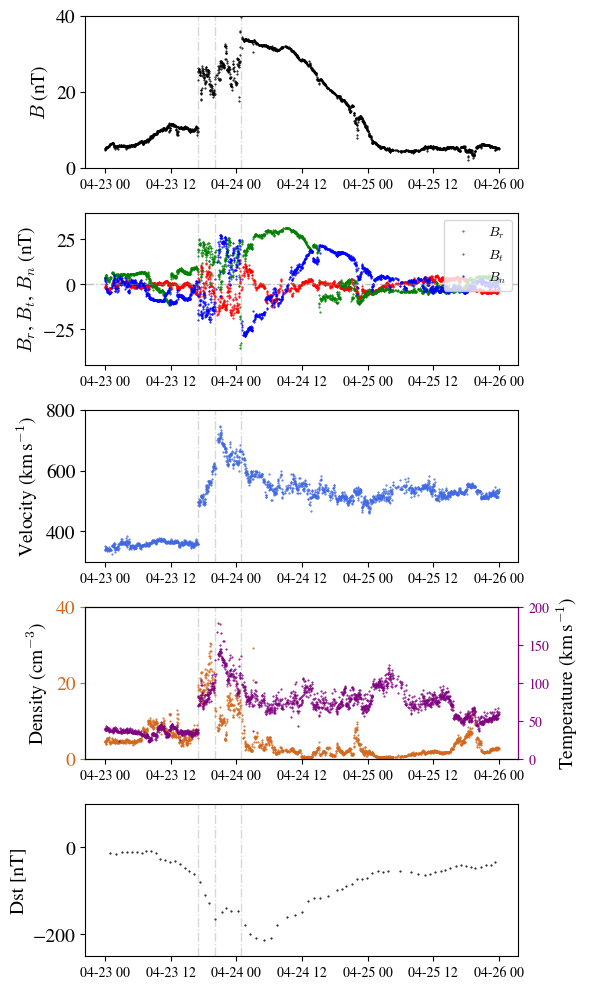

In [151]:
data_list = [
    {'dataset': WIND_MFI, 'x_col': 'Epoch', 'variables': ['B'], 'colors': ['black'],'markers':['.'], 'ylabel': '$B$ (nT)', 'ylim': (0, 40)},#,'xlim':(WIND_PLA['Epoch'][1431],WIND_PLA['Epoch'][2523]),'xticklabel':['','','','','','','','','','']},#(WIND_PLA['Epoch'][0],WIND_PLA['Epoch'][2857])},
    {'dataset': WIND_MFI, 'x_col': 'Epoch', 'variables': ['B_R', 'B_T', 'B_N'], 'colors': ['r', 'g', 'b'], 'markers': ['.', '.', '.'], 
     'labels': ['$B_r$', '$B_t$', '$B_n$'],'ylabel': '$B_r$, $B_t$, $B_n$ (nT)', 'ylim': (-45, 40)},#,'xlim':(WIND_PLA['Epoch'][1431],WIND_PLA['Epoch'][2523]),'xticklabel':['','','','','','','','','',''],'xlabel':'true'},#(WIND_PLA['Epoch'][0],WIND_PLA['Epoch'][2857])},
    {'dataset': WIND_PLA, 'x_col': 'Epoch', 'variables': ['V'], 'colors': ['royalblue'],'markers':['.'], 'ylabel': 'Velocity (km$\,$s$^{-1}$)', 'ylim': (300, 800)},#,'xlim':(WIND_PLA['Epoch'][1431],WIND_PLA['Epoch'][2523]),'xticklabel':['','','','','','','','','',''],'xlabel':'true'},#(WIND_PLA['Epoch'][0],WIND_PLA['Epoch'][2857])},
  #  {'dataset': WIND_PLA, 'x_col': 'Epoch', 'variables': ['N'], 'colors': ['chocolate'],'markers':['.'], 'ylabel': 'Density (cm$^{-3}$)', 'ylim': (0, 40),'xlabel':'true','xlim':(WIND_PLA['Epoch'][0],WIND_PLA['Epoch'][2857])}#,
    {'dataset': WIND_PLA, 'x_col': 'Epoch', 'variables': ['N'], 'colors': ['chocolate'],'markers': ['.'],'ylabel': 'Density (cm$^{-3}$)', 'ylim': (0, 40),
     # Secondary y-axis → Temperature
    'twin_variables': ['T'],
    'twin_colors': ['purple'],
    'twin_markers': ['.'],
    'twin_ylabel': 'Temperature (km$\,$s$^{-1}$)',
    'twin_ylim': (0, 200)}, 
    {'dataset': Dst_data, 'x_col': 'Epoch', 'variables': ['Dst'], 'ylabel': 'Dst [nT]', 'ylim': (-250, 100)}
#    'xlabel': 'true',
#    'xticklabel':['28  00','04','08','12','16','20','29  00','04','08','12'],
#    'xlim': (WIND_PLA['Epoch'][1431],WIND_PLA['Epoch'][2523])#(WIND_PLA['Epoch'][0], WIND_PLA['Epoch'][2857])
#}
    #    {'dataset': PSP_PLA, 'x_col': 'Epoch', 'variables': ['Vth'], 'ylabel': 'Thermal velocity [km/s]', 'ylim': (0, 200), 'xlabel': 'True'}
  
]

vlines = [553,657,791]#[1509, 1613, 1750, 2272]
print(WIND_MFIdata['Epoch'][553])

plot_data(WIND_MFI, WIND_PLA, data_list, vlines, filename='/Users/cmaccorm/Desktop/WIND_April23.png')



2023-04-23 10:00:09


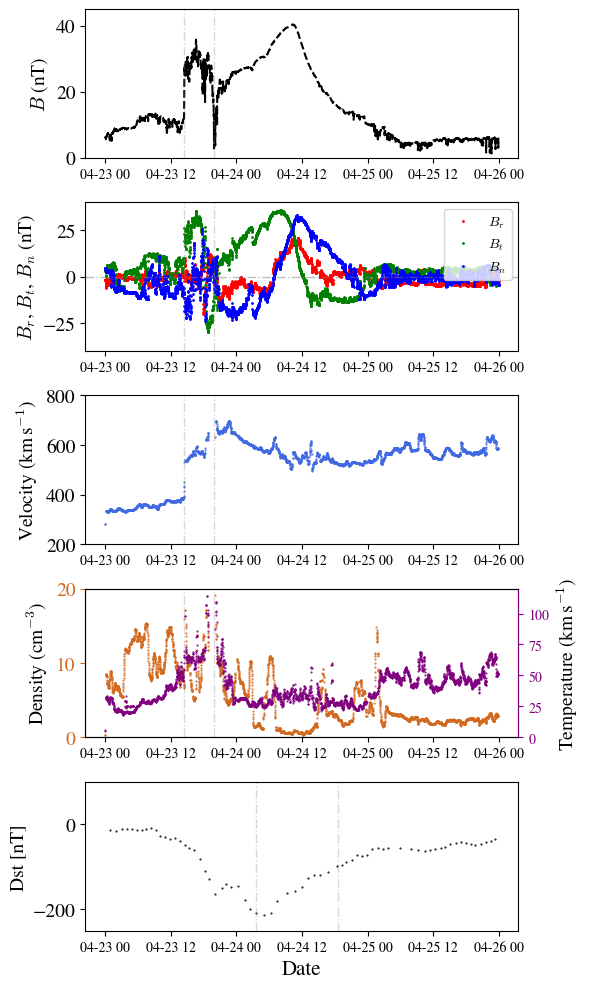

In [179]:
data_list = [
    {'dataset': sta, 'x_col': 'Epoch', 'variables': ['B'], 'colors': ['black'],'markers':['--'], 'ylabel': '$B$ (nT)', 'ylim': (0, 45)},#'xlim':(sta['Epoch'][2879],sta['Epoch'][5040]),'xticklabel':['','','','','','','','','','']},
    {'dataset': sta, 'x_col': 'Epoch', 'variables': ['B_R', 'B_T', 'B_N'], 
     'colors': ['r', 'g', 'b'], 'markers': ['o', 'o', 'o'], 
     'labels': ['$B_r$', '$B_t$', '$B_n$'],'ylabel': '$B_r$, $B_t$, $B_n$ (nT)', 'ylim': (-40, 40)},# 'xlim':(sta['Epoch'][2879],sta['Epoch'][5040]),'xticklabel':['','','','','','','','','','']},
    {'dataset': sta, 'x_col': 'Epoch', 'variables': ['V'],  'colors': ['royalblue'],'markers':['.'], 'ylabel': 'Velocity (km$\,$s$^{-1}$)', 'ylim': (200, 800)},#'xlim':(sta['Epoch'][2879],sta['Epoch'][5040]),'xticklabel':['','','','','','','','','','']},
  #  {'dataset': sta, 'x_col': 'Epoch', 'variables': ['N'], 'colors': ['chocolate'],'markers':['.'], 'ylabel': 'Density (cm$^{-3}$)', 'ylim': (0, 60),'xlabel':'true'}#,
   # {'dataset': sta, 'x_col': 'Epoch', 'variables': ['T'], 'ylabel': 'Thermal velocity [km/s]', 'ylim': (0, 200), 'xlabel':'true'}]#,
    {'dataset': sta, 'x_col': 'Epoch', 'variables': ['N'], 'colors': ['chocolate'],'markers': ['.'],'ylabel': 'Density (cm$^{-3}$)', 'ylim': (0, 20),
     # Secondary y-axis → Temperature
    'twin_variables': ['T'],
    'twin_colors': ['purple'],
    'twin_markers': ['.'],
    'twin_ylabel': 'Temperature (km$\,$s$^{-1}$)',
    'twin_ylim': (0, 120)}, 

#    'xlabel': 'true',
#    'xticklabel':['28  00','04','08','12','16','20','29  00','04','08','12'],
#    'xlim': (sta['Epoch'][2879],sta['Epoch'][5040])#(WIND_PLA['Epoch'][0], WIND_PLA['Epoch'][2857])
#}
{'dataset': Dst_data, 'x_col': 'Epoch', 'variables': ['Dst'], 'ylabel': 'Dst [nT]', 'ylim': (-250, 100), 'xlabel':'true'}
]

vlines = [865,1200]#[2561, 2716, 2744, 4249]
print(sta_data['Epoch'][600])

plot_data(sta, sta, data_list, vlines, filename='/Users/cmaccorm/Desktop/STA_April23.png')


In [151]:
from cdasws import CdasWs
cdas = CdasWs()

binData = {'interval': 600.0,'interpolateMissingValues': True,'sigmaMultiplier': 4}
status1, SOLO_MFIdata = cdas.get_data('SOLO_L2_MAG-RTN-NORMAL-1-MINUTE', ['B_RTN'],
                      '2024-10-26T06:00:00Z', '2024-10-30T00:00:00Z',binData=binData) #'2023-04-21T18:00:00Z', '2023-04-27T18:00:00Z')#'WI_K1-RTN_MFI', ['BF1', 'BRTN'],


if SOLO_MFIdata is None:
    print("Error: No data returned from cdas.get_data.")
else:
    SOLO_MFI = pd.DataFrame({
#        'Epoch': SOLO_MFIdata['EPOCH'],
        'Epoch': np.arange(len(SOLO_MFIdata['B_RTN'][:,0])),
        'B_R': SOLO_MFIdata['B_RTN'][:,0],
        'B_T': SOLO_MFIdata['B_RTN'][:,1],
        'B_N': SOLO_MFIdata['B_RTN'][:,2]
    })
    

In [152]:
from cdasws import CdasWs
cdas = CdasWs()

#binData = {'interval': 900.0,'interpolateMissingValues': False,'sigmaMultiplier': 4}
status1, SOLO_MFIdata = cdas.get_data('SOLO_L2_MAG-RTN-NORMAL-1-MINUTE', ['B_RTN'],
                      '2024-10-26T06:00:00Z', '2024-10-30T00:00:00Z')#,binData=binData) #'2023-04-21T18:00:00Z', '2023-04-27T18:00:00Z')#'WI_K1-RTN_MFI', ['BF1', 'BRTN'],

if SOLO_MFIdata is None:
    print("Error: No data returned from cdas.get_data.")
else:
    SOLO_MFI = pd.DataFrame({
        'Epoch': SOLO_MFIdata['EPOCH'],
#        'Epoch': np.arange(len(SOLO_MFIdata['B_RTN'][:,0])),
        'B_R': SOLO_MFIdata['B_RTN'][:,0],
        'B_T': SOLO_MFIdata['B_RTN'][:,1],
        'B_N': SOLO_MFIdata['B_RTN'][:,2]
    })

#'B_N': WIND_MFIdata['BRTN'][:,2]


#binData = {'interval': 900.0,'interpolateMissingValues': False,'sigmaMultiplier': 4}
status2, SOLO_PLAdata = cdas.get_data('SOLO_L2_SWA-PAS-GRND-MOM', ['V_RTN','N', 'T'], #T in eV
                      '2024-10-26T06:00:00Z', '2024-10-30T00:00:00Z')#,binData=binData) #'2023-04-21T18:00:00Z', '2023-04-27T18:00:00Z')

if SOLO_PLAdata is None:
    print("Error: No data returned from cdas.get_data.")
else:
    SOLO_PLA = pd.DataFrame({
        'Epoch': SOLO_PLAdata['Epoch'],
#        'Epoch': np.arange(len(SOLO_PLAdata['N'])),
        'N' : SOLO_PLAdata['N'],
        'T' : SOLO_PLAdata['T'],
        'V_R' : SOLO_PLAdata['V_RTN'][:,0],
        'V_T' : SOLO_PLAdata['V_RTN'][:,1],
        'V_N' : SOLO_PLAdata['V_RTN'][:,2]
    })

SOLO_MFI['B'] = np.sqrt(SOLO_MFI['B_R']**2 + SOLO_MFI['B_T']**2 + SOLO_MFI['B_N']**2)
SOLO_PLA['V'] = np.sqrt(SOLO_PLA['V_R']**2 + SOLO_PLA['V_T']**2 + SOLO_PLA['V_N']**2)



/var/folders/sc/h0kgzw2j30z63q5zkknhcjhh0000gp/T/ipykernel_94864/3030121341.py:73: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[i].set_xticklabels(xticklabel,rotation=17,fontsize=14)#['','','27','','28','','29','','30'])


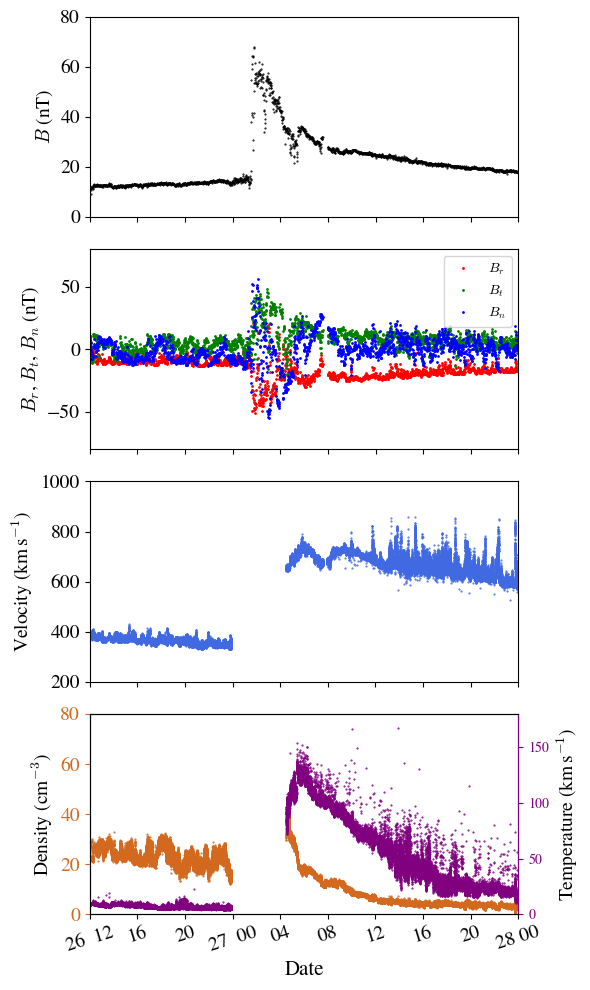

In [220]:
data_list = [
    {'dataset': SOLO_MFI, 'x_col': 'Epoch', 'variables': ['B'], 'colors': ['black'],'markers':['.'], 'ylabel': '$B$ (nT)', 'ylim': (0, 80),'xlim': (SOLO_MFI['Epoch'][359],SOLO_MFI['Epoch'][2496]),'xticklabel':['','','','','','','','']},
    {'dataset': SOLO_MFI, 'x_col': 'Epoch', 'variables': ['B_R', 'B_T', 'B_N'], 
    'colors': ['r', 'g', 'b'], 'markers': ['o', 'o', 'o'], 
     'labels': ['$B_r$', '$B_t$', '$B_n$'],'ylabel': '$B_r$, $B_t$, $B_n$ (nT)', 'ylim': (-80, 80),'xlim': (SOLO_MFI['Epoch'][359],SOLO_MFI['Epoch'][2496]),'xticklabel':['','','','','','','','']},
    {'dataset': SOLO_PLA, 'x_col': 'Epoch', 'variables': ['V'],  'colors': ['royalblue'],'markers':['.'], 'ylabel': 'Velocity (km$\,$s$^{-1}$)', 'ylim': (200, 1000),'xlim': (SOLO_PLA['Epoch'][20096],SOLO_PLA['Epoch'][125000]),'xticklabel':['','','','','','','','']},
   # {'dataset': SOLO_PLA, 'x_col': 'Epoch', 'variables': ['N'],'colors': ['chocolate'],'markers':['.'], 'ylabel': 'Density (cm$^{-3}$)', 'ylim': (0, 60),'xlim': (SOLO_PLA['Epoch'][2879],SOLO_PLA['Epoch'][5040]),'xticklabel':['','','','','','','',''],'xlabel':'true'}#,
  #  {'dataset': SOLO_PLA, 'x_col': 'Epoch', 'variables': ['T'], 'ylabel': 'Thermal velocity [km/s]', 'ylim': (0, 200), 'xlabel':'true'}]#,
   # {'dataset': Dst_data, 'x_col': 'Epoch', 'variables': ['Dst'], 'ylabel': 'Dst [nT]', 'ylim': (-250, 100), 'xlabel':'true'}
    {'dataset': SOLO_PLA, 'x_col': 'Epoch', 'variables': ['N'], 'colors': ['chocolate'],'markers': ['.'],'ylabel': 'Density (cm$^{-3}$)', 'ylim': (0, 80),
     # Secondary y-axis → Temperature
    'twin_variables': ['T'],
    'twin_colors': ['purple'],
    'twin_markers': ['.'],
    'twin_ylabel': 'Temperature (km$\,$s$^{-1}$)',
    'twin_ylim': (0, 180), 

    'xlabel': 'true',
    'xticklabel':['26  12','16','20','27  00','04','08','12','16','20','28 00'],
    'xlim': (SOLO_PLA['Epoch'][20096],SOLO_PLA['Epoch'][125000])#(WIND_PLA['Epoch'][0], WIND_PLA['Epoch'][2857])
}
]

#'xtick': [0,3089,6179,9269,12358], 'xticklabel':['26','27','28','29','30']

vlines = [79]#5165]#[2561, 2716, 2744, 4249]
#print(SOLO_MFIdata['EPOCH'][5165])

plot_data(SOLO_MFI, SOLO_PLA, data_list, vlines, filename='/Users/cmaccorm/Desktop/SOLO_October26.png')



In [450]:
from cdasws import CdasWs
cdas = CdasWs()

binData = {'interval': 600.0,'interpolateMissingValues': True,'sigmaMultiplier': 4}
status1, PSP_data = cdas.get_data('PSP_COHO1HR_MERGED_MAG_PLASMA', ['BR', 'BT', 'BN', 'B', 'VR', 'VT', 'VN', 'protonSpeed','protonDensity', 'protonTemp'],
                      '2024-10-26T06:00:00Z', '2024-11-01T12:00:00Z',binData=binData) #'2023-04-21T18:00:00Z', '2023-04-27T18:00:00Z')#'WI_K1-RTN_MFI', ['BF1', 'BRTN'],


#status1, PSP_MFIdata = cdas.get_data('PSP_FLD_L2_MAG_RTN_1MIN', ['B_R', 'B_T', 'B_N'],
#                      '2024-10-26T06:00:00Z', '2024-11-01T12:00:00Z') #'2023-04-21T18:00:00Z', '2023-04-27T18:00:00Z')#'WI_K1-RTN_MFI', ['BF1', 'BRTN'],

if PSP_data is None:
    print("Error: No data returned from cdas.get_data.")
else:
    PSP = pd.DataFrame({
        'Epoch': PSP_data['EPOCH'],
        'B_R': PSP_data['B_R'],
        'B_T': PSP_data['B_T'],
        'B_N': PSP_data['B_N'],
        'N' : PSP_data['protonDensity'],
        'T' : PSP_data['protonTemp'],
        'V' : PSP_data['protonSpeed']
    })



#if PSP_MFIdata is None:
#    print("Error: No data returned from cdas.get_data.")
#else:
#    PSP_MFI = pd.DataFrame({
#        'Epoch': PSP_MFIdata['EPOCH'],
#        'B_R': PSP_MFIdata['B_R'],
#        'B_T': PSP_MFIdata['B_T'],
#        'B_N': PSP_MFIdata['B_N']
#    })

#'B_N': WIND_MFIdata['BRTN'][:,2]

#status2, PSP_PLAdata = cdas.get_data('PSP_SWP_SPC_L3I', ['vp_moment_RTN','np_moment','wp_moment'],
#                      '2024-10-26T06:00:00Z', '2024-11-01T12:00:00Z') #'2023-04-21T18:00:00Z', '2023-04-27T18:00:00Z')

# Create DataFrame
#if PSP_PLAdata is None:
#    print("Error: No data returned from cdas.get_data.")
#else:
#    PSP_PLA = pd.DataFrame({
#        'Epoch': PSP_PLAdata['Epoch'],
#        'N' : PSP_PLAdata['np_moment'],
#        'T' : PSP_PLAdata['wp_moment'],
#        'V_R' : PSP_PLAdata['vp_moment_RTN'][:,0],
#        'V_T' : PSP_PLAdata['vp_moment_RTN'][:,1],
#        'V_N' : PSP_PLAdata['vp_moment_RTN'][:,2]
#    })

PSP['B'] = np.sqrt(PSP['B_R']**2 + PSP['B_T']**2 + PSP['B_N']**2)
#PSP_MFI['B'] = np.sqrt(PSP_MFI['B_R']**2 + PSP_MFI['B_T']**2 + PSP_MFI['B_N']**2)
#PSP_PLA['V'] = np.sqrt(PSP_PLA['V_R']**2 + PSP_PLA['V_T']**2 + PSP_PLA['V_N']**2)




Error: No data returned from cdas.get_data.


KeyError: 'B_R'

In [222]:
from pathlib import Path
import ssl
import copy

from ai import cdas
import pandas as pd
import numpy as np

def read_psp_mag(start, end, cache_dir='./cdas-data'):

    ssl._create_default_https_context = ssl._create_unverified_context 

    cache_dir = Path(cache_dir)
    if not cache_dir.exists():
        cache_dir.mkdir(parents=True)
    cdas.set_cache(True, cache_dir)

    dataset = 'PSP_FLD_L2_MAG_RTN_1MIN'
    vlist = ['psp_fld_l2_mag_RTN_1min'] 
    
    try:
        data = cdas.get_data('sp_phys', dataset, start, end, variables=vlist)
    except:
        print(f"CDAS Error loading {dataset} data for this date range")
        return pd.DataFrame()

    map_names = {'date_time':data['EPOCH'],
                'Br':data['B_R'],
                'Bt':data['B_T'],
                'Bn':data['B_N']}
    df = pd.DataFrame(data=map_names)
    df['B'] = np.sqrt(data['B_R']**2 + data['B_T']**2 + data['B_N']**2)
    df['ddoy'] = df.date_time.dt.day_of_year \
                + (df.date_time.dt.hour + (df.date_time.dt.minute)/60 \
                + (df.date_time.dt.second)/3600)/24
    df.set_index('date_time', inplace=True)

    # Rudimentary quality filter
    df.where(df > -1.0e+29, np.nan, inplace=True)
    df.where(df < 1.0e+29, np.nan, inplace=True)

    # Store metadata
    df.attrs['data_source'] = f'FIELDS L2 1 minute dataset [{dataset}]'
    df.attrs['timezone'] = 'UTC'    
    df.Br.attrs['unit'] = 'nT'
    df.Bt.attrs['unit'] = 'nT'
    df.Bn.attrs['unit'] = 'nT'
    df.B.attrs['unit'] = 'nT'

    units = {}
    for c in df:
        if 'unit' in df[c].attrs:
            units[c] = df[c].attrs['unit']

    if len(units) > 0:
        df.attrs['units'] = units
        
    return df

In [21]:
PSP = read_psp_mag('2024-10-26T06:00:00Z', '2024-11-01T12:00:00Z')

CDAS Error loading PSP_FLD_L2_MAG_RTN data for this date range


In [223]:
from pathlib import Path
import ssl
import copy

from ai import cdas
import pandas as pd
import numpy as np
def read_psp_ion(start, end, cache_dir='./cdas-data'):

    ssl._create_default_https_context = ssl._create_unverified_context 

    cache_dir = Path(cache_dir)
    if not cache_dir.exists():
        cache_dir.mkdir(parents=True)
    cdas.set_cache(True, cache_dir)

    dataset = 'PSP_SWP_SPC_L3I'
    vlist = ['vp_moment_RTN','np_moment','wp_moment','general_flag']
    try:
        data = cdas.get_data('sp_phys', dataset, start, end, variables=vlist)
    except:
        print(f"CDAS Error loading {dataset} data for this date range")
        return pd.DataFrame()


    map_names = {'date_time':data['EPOCH'],
            'Np':data['NP_MOMENT'],
            'Vth':data['WP_MOMENT'],
            'Vr':data['VP_MOMENT_R'],
            'Vt':data['VP_MOMENT_T'],
            'Vn':data['VP_MOMENT_N'],
            'general_flag':data['GENERAL_FLAG']  
            }
    df = pd.DataFrame(data=map_names)            
    df['Vsw'] = np.sqrt(data['VP_MOMENT_R']**2 + data['VP_MOMENT_T']**2 + data['VP_MOMENT_N']**2)
    df['ddoy'] = df.date_time.dt.day_of_year \
                + (df.date_time.dt.hour + (df.date_time.dt.minute)/60 \
                + (df.date_time.dt.second)/3600)/24
    df.set_index('date_time', inplace=True)
    df.where(df > -1.0e+29, np.nan, inplace=True)
    df.where(df < 1.0e+29, np.nan, inplace=True)
    # Quality filter. General flag = 0 is good with no caveats.
    # df = df[df.general_flag == 0].copy()
    df.drop(columns='general_flag', inplace=True)

    # Set metadata
    df.attrs['data_source'] = f'SPC L3 dataset [{dataset}]; Filtered on general quality flag'
    df.attrs['timezone'] = 'UTC'
    df.Np.attrs['unit'] = 'cm^{-3}'
    df.Vth.attrs['unit'] = 'km/s'
    df.Vr.attrs['unit'] = 'km/s'
    df.Vt.attrs['unit'] = 'km/s'
    df.Vn.attrs['unit'] = 'km/s'
    df.Vsw.attrs['unit'] = 'km/s'

    units = {}
    for c in df:
        if 'unit' in df[c].attrs:
            units[c] = df[c].attrs['unit']

    if len(units) > 0:
        df.attrs['units'] = units

    return df

In [274]:
PSP = read_psp_ion('2024-10-26T06:00:00Z', '2024-11-01T12:00:00Z')

CDAS Error loading PSP_SWP_SPC_L3I data for this date range


In [227]:
import numpy as np
import pandas as pd
from spacepy import pycdf

cdf_files = [
    '/Users/cmaccorm/Downloads/PSP_Oct/psp_fld_l2_mag_rtn_1min_20241026_v02.cdf',
    '/Users/cmaccorm/Downloads/PSP_Oct/psp_fld_l2_mag_rtn_1min_20241027_v02.cdf',
    '/Users/cmaccorm/Downloads/PSP_Oct/psp_fld_l2_mag_rtn_1min_20241028_v02.cdf',
    '/Users/cmaccorm/Downloads/PSP_Oct/psp_fld_l2_mag_rtn_1min_20241029_v02.cdf',
  #  '/Users/cmaccorm/Downloads/PSP_Oct/psp_fld_l2_mag_rtn_1min_20241030_v02.cdf',
  #  '/Users/cmaccorm/Downloads/PSP_Oct/psp_fld_l2_mag_rtn_1min_20241031_v02.cdf',
  #  '/Users/cmaccorm/Downloads/PSP_Oct/psp_fld_l2_mag_rtn_1min_20241101_v02.cdf'
]

pcdf_files = [
    '/Users/cmaccorm/Downloads/PSP_Oct/psp_swp_spc_l3i_20241026_v02.cdf',
    '/Users/cmaccorm/Downloads/PSP_Oct/psp_swp_spc_l3i_20241027_v02.cdf',
    '/Users/cmaccorm/Downloads/PSP_Oct/psp_swp_spc_l3i_20241028_v02.cdf',
    '/Users/cmaccorm/Downloads/PSP_Oct/psp_swp_spc_l3i_20241029_v02.cdf',
   # '/Users/cmaccorm/Downloads/PSP_Oct/psp_swp_spc_l3i_20241030_v02.cdf',
   # '/Users/cmaccorm/Downloads/PSP_Oct/psp_swp_spc_l3i_20241031_v02.cdf',
   # '/Users/cmaccorm/Downloads/PSP_Oct/psp_swp_spc_l3i_20241101_v02.cdf'
]
#binData = {'interval': 600.0,'interpolateMissingValues': True,'sigmaMultiplier': 4}


cdfs = [pycdf.CDF(f) for f in cdf_files]
pcdfs = [pycdf.CDF(f) for f in pcdf_files]

def extract_data(cdfs, idx):
    return np.concatenate([cdf[1][:, idx] for cdf in cdfs])

BR = extract_data(cdfs, 0)
BT = extract_data(cdfs, 1)
BN = extract_data(cdfs, 2)

TT = np.concatenate([cdf[4][:1439] for cdf in cdfs])

PSP_MAG = pd.DataFrame({
    'Epoch': np.arange(len(BR)),
    'B_R': BR,
    'B_T': BT,
    'B_N': BN,
})

PSP_MAG['B'] = np.sqrt(PSP_MAG['B_R']**2 + PSP_MAG['B_T']**2 + PSP_MAG['B_N']**2)

def extract_plasma_data(pcdfs, var_name):
    return np.concatenate([pcdf[var_name][:] for pcdf in pcdfs])

V_R = extract_plasma_data(pcdfs, 'vp_moment_RTN')[:, 0]
V_T = extract_plasma_data(pcdfs, 'vp_moment_RTN')[:, 1]
V_N = extract_plasma_data(pcdfs, 'vp_moment_RTN')[:, 2]
N = extract_plasma_data(pcdfs, 'np_moment')
Vth = extract_plasma_data(pcdfs, 'wp_moment')

Tp = np.concatenate([pcdf['Epoch'][:] for pcdf in pcdfs])

PSP_PLA = pd.DataFrame({
    'Epoch': Tp,
    'Epoch1': np.arange(len(N)),
    'V_R': V_R,
    'V_T': V_T,
    'V_N': V_N,
    'N': N,
    'Vth': Vth
})

PSP_PLA['V'] = np.sqrt(PSP_PLA['V_R']**2 + PSP_PLA['V_T']**2 + PSP_PLA['V_N']**2)


In [285]:
PSP_PLA['Vth'][1544:6180]

1544    3.781310e+01
1545    3.868583e+01
1546    3.549059e+01
1547    3.579058e+01
1548    4.580671e+01
            ...     
6175   -1.000000e+31
6176   -1.000000e+31
6177   -1.000000e+31
6178   -1.000000e+31
6179   -1.000000e+31
Name: Vth, Length: 4636, dtype: float32

/var/folders/sc/h0kgzw2j30z63q5zkknhcjhh0000gp/T/ipykernel_94864/3030121341.py:73: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[i].set_xticklabels(xticklabel,rotation=17,fontsize=14)#['','','27','','28','','29','','30'])


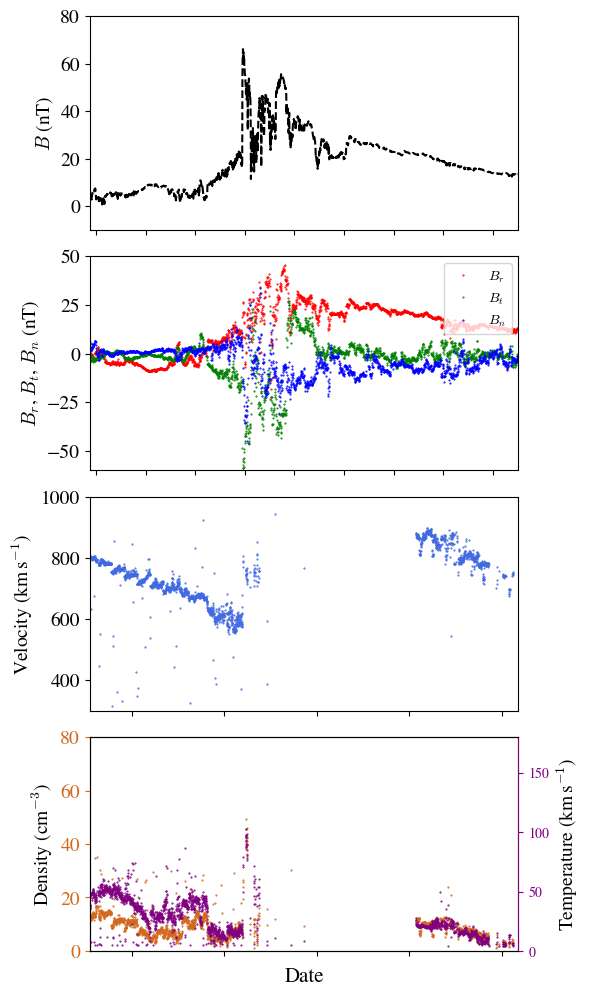

In [290]:
data_list = [
    {'dataset': PSP_MAG, 'x_col': 'Epoch', 'variables': ['B'], 'colors': ['black'],'markers':['--'], 'ylabel': '$B$ (nT)', 'ylim': (-10, 80), 'xlim':(719,2879), 'xticklabel':['','','','','','']},
    {'dataset': PSP_MAG, 'x_col': 'Epoch', 'variables': ['B_R', 'B_T', 'B_N'], 'colors': ['r', 'g', 'b'], 'markers': ['.', '.', '.'], 
     'labels': ['$B_r$', '$B_t$', '$B_n$'],'ylabel': '$B_r$, $B_t$, $B_n$ (nT)', 'ylim': (-60, 50), 'xlim':(719,2879), 'xticklabel':['','','','','','']},
    {'dataset': PSP_PLA, 'x_col': 'Epoch1', 'variables': ['V'], 'colors': ['royalblue'],'markers':['.'], 'ylabel': 'Velocity (km$\,$s$^{-1}$)', 'ylim': (300, 1000), 'xlim':(1544,6180), 'xticklabel':['','','','','','']},
#    {'dataset': PSP_PLA, 'x_col': 'Epoch1', 'variables': ['N'], 'colors': ['chocolate'],'markers':['.'], 'ylabel': 'Density (cm$^{-3}$)', 'ylim': (-10, 40), 'xlim':(1544,6180),'xlabel':'true'}#,
#    {'dataset': PSP_PLA, 'x_col': 'Epoch', 'variables': ['Vth'], 'ylabel': 'Thermal velocity [km/s]', 'ylim': (0, 200), 'xlabel': 'True'}
    {'dataset': PSP_PLA, 'x_col': 'Epoch1', 'variables': ['N'], 'colors': ['chocolate'],'markers': ['.'],'ylabel': 'Density (cm$^{-3}$)', 'ylim': (0, 80),
     # Secondary y-axis → Temperature
    'twin_variables': ['Vth'],
    'twin_colors': ['purple'],
    'twin_markers': ['.'],
    'twin_ylabel': 'Temperature (km$\,$s$^{-1}$)',
    'twin_ylim': (0, 180), 

    'xlabel': 'true', 'xticklabel':['','','','','',''],
  #  'xticklabel':['26  12','16','20','27  00','04','08','12','16','20','28 00'],
    'xlim':(1544,6180)#(WIND_PLA['Epoch'][0], WIND_PLA['Epoch'][2857])
}
]

vlines = [] 
#print(Tp[3170])

plot_data(PSP_MAG, PSP_PLA, data_list, vlines, filename='/Users/cmaccorm/Desktop/PSP_October26.png')


In [226]:
TT[1488],PSP_MAG['Epoch'][1488]

(datetime.datetime(2024, 10, 27, 0, 49), 1488)